# Speculative Decoding, From Scratch

A correct, hand-written implementation of speculative decoding (Leviathan et al. 2023 / Chen et al. 2023), benchmarked on a real GPU.

**In Kaggle: enable a GPU before running** — Settings (right sidebar) → Accelerator → GPU T4 x2 (or P100).

## What this notebook does

1. Implements speculative decoding: a small **draft model** (`distilgpt2`) proposes several tokens at once, a big **target model** (`gpt2-medium`) verifies them all in a single forward pass, and each is accepted or rejected with the exact probability that guarantees the output distribution matches the target model alone.
2. **Proves correctness**: at near-zero temperature both models become deterministic, so speculative decoding must reduce to exactly the target model's own greedy output. The notebook checks this with an exact token-for-token match — not just "the text looks plausible."
3. **Benchmarks it for real**: measures actual wall-clock tokens/sec for speculative decoding vs. plain autoregressive decoding (both KV-cached, so it's a fair comparison), and reports the acceptance rate.

This was first built and validated on CPU (see the correctness test), where speculative decoding's speed benefit doesn't show up — CPUs don't have the idle parallel compute that makes "verify 4 tokens at once" nearly free the way a GPU does. This notebook is where we find out if that theory holds.

## 1. Setup

In [1]:
import sys
# Skip on an environment that already has everything (e.g. running locally
# in a pre-built venv). On a fresh Kaggle kernel this installs what's needed.
try:
    import transformers, torch  # noqa
    print("transformers/torch already available, skipping install.")
except ImportError:
    get_ipython().system('pip install -q -U transformers torch')

import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected. In Kaggle: Settings -> Accelerator -> GPU, then re-run this cell.")

C:\Users\Shifter\Ocular\speculative-decoding-with-a-speculative-vocabulary\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers/torch already available, skipping install.
torch: 2.13.0+cpu
CUDA available: False


## 2. The implementation

Both functions use `DynamicCache` so neither model ever reprocesses a token it has already seen. When a draft token is rejected, both caches get cropped back to the last accepted position with `.crop()` rather than rebuilt from scratch — that's what makes this actually fast, not just theoretically correct.

In [2]:
import time
from dataclasses import dataclass

import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, DynamicCache


@dataclass
class SpecDecodeStats:
    proposed_tokens: int = 0
    accepted_tokens: int = 0
    steps: int = 0

    @property
    def acceptance_rate(self) -> float:
        return self.accepted_tokens / self.proposed_tokens if self.proposed_tokens else 0.0


def _sample(probs: torch.Tensor) -> int:
    return torch.multinomial(probs, num_samples=1).item()


def _step(model, token_ids: torch.Tensor, cache: DynamicCache):
    """Feed `token_ids` (new, not-yet-cached tokens) through `model`,
    extending `cache` in place. Returns logits for every fed position."""
    with torch.no_grad():
        out = model(input_ids=token_ids, past_key_values=cache, use_cache=True)
    return out.logits, out.past_key_values

In [3]:
@torch.no_grad()
def speculative_decode(
    prompt_ids: torch.Tensor,
    draft_model,
    target_model,
    max_new_tokens: int,
    lookahead: int = 4,
    temperature: float = 1.0,
    eos_token_id=None,
):
    stats = SpecDecodeStats()
    ids = prompt_ids.clone()
    device = ids.device
    prompt_len = ids.shape[1]

    # Prime both caches on the prompt. Each "pending logits" predicts the
    # very next token (position len(ids), not chosen yet).
    draft_logits, draft_cache = _step(draft_model, ids, DynamicCache())
    target_logits, target_cache = _step(target_model, ids, DynamicCache())
    draft_pending = draft_logits[0, -1, :]
    target_pending = target_logits[0, -1, :]

    while ids.shape[1] - prompt_len < max_new_tokens:
        stats.steps += 1
        base_len = ids.shape[1]  # cache length before this round's draft tokens

        # 1. Draft proposes `lookahead` tokens, one at a time, cache growing normally.
        draft_tokens, draft_dists = [], []
        pending = draft_pending
        for _ in range(lookahead):
            probs = F.softmax(pending / temperature, dim=-1)
            tok = _sample(probs)
            draft_tokens.append(tok)
            draft_dists.append(probs)
            logits, draft_cache = _step(draft_model, torch.tensor([[tok]], device=device), draft_cache)
            pending = logits[0, -1, :]

        # 2. Target verifies all `lookahead` tokens in ONE forward pass.
        draft_tensor = torch.tensor([draft_tokens], device=device)
        batch_logits, target_cache_full = _step(target_model, draft_tensor, target_cache)
        # target_pending (from end of last round) verifies draft_tokens[0];
        # batch_logits[0, i, :] verifies draft_tokens[i+1] for i in 0..lookahead-2,
        # and batch_logits[0, lookahead-1, :] is the bonus-token prediction.
        target_dists = [target_pending] + [batch_logits[0, i, :] for i in range(lookahead - 1)]

        # 3. Accept/reject in order.
        n_accepted = 0
        rejected = False
        for i, tok in enumerate(draft_tokens):
            target_probs = F.softmax(target_dists[i] / temperature, dim=-1)
            p_target = target_probs[tok].item()
            p_draft = draft_dists[i][tok].item()
            accept_prob = min(1.0, p_target / max(p_draft, 1e-10))
            stats.proposed_tokens += 1

            if torch.rand(1).item() < accept_prob:
                ids = torch.cat([ids, torch.tensor([[tok]], device=device)], dim=1)
                n_accepted += 1
                stats.accepted_tokens += 1
                if eos_token_id is not None and tok == eos_token_id:
                    target_cache_full.crop(base_len + n_accepted)
                    return ids[:, : prompt_len + max_new_tokens], stats
            else:
                adjusted = torch.clamp(target_probs - draft_dists[i], min=0.0)
                total = adjusted.sum()
                adjusted = adjusted / total if total > 0 else target_probs
                resampled = _sample(adjusted)
                ids = torch.cat([ids, torch.tensor([[resampled]], device=device)], dim=1)
                rejected = True
                # Roll BOTH caches back to just the accepted prefix, then feed
                # the resampled token to extend them by exactly one.
                target_cache_full.crop(base_len + n_accepted)
                draft_cache.crop(base_len + n_accepted)
                resampled_t = torch.tensor([[resampled]], device=device)
                tlogits, target_cache = _step(target_model, resampled_t, target_cache_full)
                dlogits, draft_cache = _step(draft_model, resampled_t, draft_cache)
                target_pending = tlogits[0, -1, :]
                draft_pending = dlogits[0, -1, :]
                break

        if not rejected:
            # All `lookahead` tokens accepted -> take the free bonus token.
            bonus_probs = F.softmax(batch_logits[0, lookahead - 1, :] / temperature, dim=-1)
            bonus = _sample(bonus_probs)
            ids = torch.cat([ids, torch.tensor([[bonus]], device=device)], dim=1)
            bonus_t = torch.tensor([[bonus]], device=device)
            tlogits, target_cache = _step(target_model, bonus_t, target_cache_full)
            dlogits, draft_cache = _step(draft_model, bonus_t, draft_cache)
            target_pending = tlogits[0, -1, :]
            draft_pending = dlogits[0, -1, :]
            if eos_token_id is not None and bonus == eos_token_id:
                return ids[:, : prompt_len + max_new_tokens], stats

    return ids[:, : prompt_len + max_new_tokens], stats


@torch.no_grad()
def naive_decode(
    prompt_ids: torch.Tensor,
    target_model,
    max_new_tokens: int,
    temperature: float = 1.0,
    eos_token_id=None,
):
    """Baseline: target model generates one token at a time, WITH caching
    (this is the fair comparison -- a real system would always cache)."""
    ids = prompt_ids.clone()
    logits, cache = _step(target_model, ids, DynamicCache())
    pending = logits[0, -1, :]
    for _ in range(max_new_tokens):
        probs = F.softmax(pending / temperature, dim=-1)
        tok = _sample(probs)
        ids = torch.cat([ids, torch.tensor([[tok]], device=ids.device)], dim=1)
        if eos_token_id is not None and tok == eos_token_id:
            break
        logits, cache = _step(target_model, torch.tensor([[tok]], device=ids.device), cache)
        pending = logits[0, -1, :]
    return ids

## 3. Load the real models

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
print("Loading draft model (distilgpt2)...")
draft_model = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device).eval()
print("Loading target model (gpt2-medium)...")
target_model = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(device).eval()
print("Done.")

Using device: cpu


Loading draft model (distilgpt2)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 3449.49it/s]

Loading target model (gpt2-medium)...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loading weights:  51%|█████▏    | 150/292 [00:00<00:00, 1494.57it/s]

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 1703.20it/s]

Done.


## 4. Correctness check (do this before trusting any speed numbers)

At near-zero temperature both models become deterministic (always pick their own top token). In that regime, speculative decoding **must** produce the exact same token sequence as plain greedy decoding from the target model alone — that's the whole mathematical guarantee of the technique. If this doesn't match exactly, the accept/reject logic has a bug and the speed numbers below aren't trustworthy.

In [5]:
torch.manual_seed(0)
prompt = "Once upon a time"
prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

torch.manual_seed(0)
spec_ids, _stats = speculative_decode(
    prompt_ids, draft_model, target_model, max_new_tokens=30, lookahead=4, temperature=1e-4
)
torch.manual_seed(0)
naive_ids = naive_decode(prompt_ids, target_model, max_new_tokens=30, temperature=1e-4)

print("Speculative:", tokenizer.decode(spec_ids[0], skip_special_tokens=True))
print("Naive greedy:", tokenizer.decode(naive_ids[0], skip_special_tokens=True))

match = torch.equal(spec_ids, naive_ids)
print("\nEXACT MATCH:", match)
assert match, "Correctness check failed -- do not trust the benchmark below."
print("PASS: speculative decoding reduces to target-model greedy decoding, as required.")

Speculative: Once upon a time, there was a man who lived in a village called Krakow. He was a very good man, and he was very kind to his children
Naive greedy: Once upon a time, there was a man who lived in a village called Krakow. He was a very good man, and he was very kind to his children

EXACT MATCH: True
PASS: speculative decoding reduces to target-model greedy decoding, as required.


## 5. The real benchmark

In [6]:
prompts = [
    "The future of artificial intelligence is",
    "In a small village nestled in the mountains,",
    "The most important thing to understand about economics is",
]
# Auto-scale down on CPU so this finishes in a reasonable time; on a real
# GPU (Kaggle T4/P100) the full 3-prompt x 100-token run is fast.
if device == "cpu":
    prompts = prompts[:2]
    max_new_tokens = 40
    print("No GPU detected -- reduced to 2 prompts x 40 tokens for a reasonable CPU runtime.")
else:
    max_new_tokens = 100
lookahead = 4

results = []
for prompt in prompts:
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    torch.manual_seed(0)
    t0 = time.perf_counter()
    spec_ids, stats = speculative_decode(
        prompt_ids, draft_model, target_model, max_new_tokens, lookahead=lookahead
    )
    spec_time = time.perf_counter() - t0

    torch.manual_seed(0)
    t0 = time.perf_counter()
    naive_ids = naive_decode(prompt_ids, target_model, max_new_tokens)
    naive_time = time.perf_counter() - t0

    results.append({
        "prompt": prompt,
        "spec_time": spec_time,
        "naive_time": naive_time,
        "speedup": naive_time / spec_time,
        "acceptance_rate": stats.acceptance_rate,
        "target_forward_passes": stats.steps,
        "spec_text": tokenizer.decode(spec_ids[0], skip_special_tokens=True),
    })

    print(f"Prompt: {prompt!r}")
    print(f"  Speculative: {spec_time:.2f}s ({max_new_tokens/spec_time:.1f} tok/s), "
          f"{stats.steps} target forward passes (vs {max_new_tokens} for naive)")
    print(f"  Naive:       {naive_time:.2f}s ({max_new_tokens/naive_time:.1f} tok/s)")
    print(f"  Acceptance rate: {stats.acceptance_rate:.1%}")
    print(f"  Speedup: {naive_time/spec_time:.2f}x\n")

No GPU detected -- reduced to 2 prompts x 40 tokens for a reasonable CPU runtime.


Prompt: 'The future of artificial intelligence is'
  Speculative: 13.99s (2.9 tok/s), 13 target forward passes (vs 40 for naive)
  Naive:       10.55s (3.8 tok/s)
  Acceptance rate: 76.9%
  Speedup: 0.75x



Prompt: 'In a small village nestled in the mountains,'
  Speculative: 22.45s (1.8 tok/s), 21 target forward passes (vs 40 for naive)
  Naive:       12.34s (3.2 tok/s)
  Acceptance rate: 51.3%
  Speedup: 0.55x



In [7]:
import statistics

avg_speedup = statistics.mean(r["speedup"] for r in results)
avg_acceptance = statistics.mean(r["acceptance_rate"] for r in results)
print(f"Average speedup across {len(results)} prompts: {avg_speedup:.2f}x")
print(f"Average acceptance rate: {avg_acceptance:.1%}")
print(f"Device: {device}")

Average speedup across 2 prompts: 0.65x
Average acceptance rate: 64.1%
Device: cpu


## 6. Plot the results

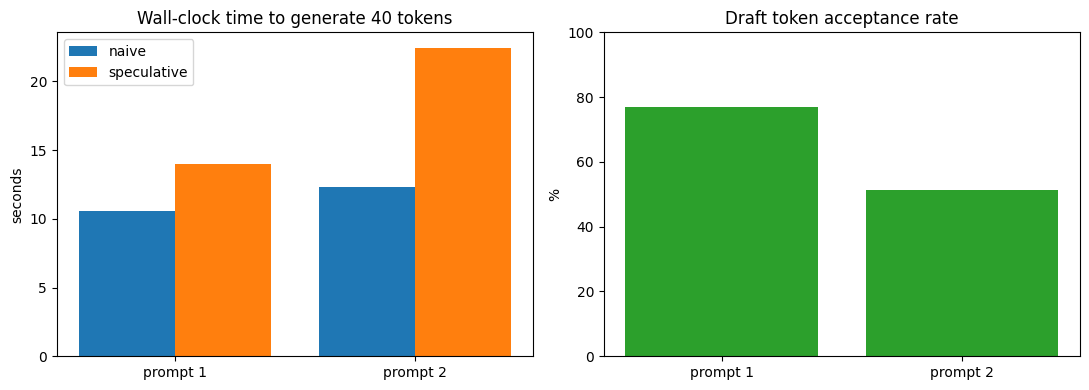

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = [f"prompt {i+1}" for i in range(len(results))]
x = range(len(results))

axes[0].bar([i - 0.2 for i in x], [r["naive_time"] for r in results], width=0.4, label="naive")
axes[0].bar([i + 0.2 for i in x], [r["spec_time"] for r in results], width=0.4, label="speculative")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("seconds")
axes[0].set_title(f"Wall-clock time to generate {max_new_tokens} tokens")
axes[0].legend()

axes[1].bar(list(x), [r["acceptance_rate"] * 100 for r in results], color="tab:green")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("%")
axes[1].set_ylim(0, 100)
axes[1].set_title("Draft token acceptance rate")

plt.tight_layout()
plt.savefig("speculative_decoding_results.png", dpi=150)
plt.show()

## Notes / honest caveats

- `distilgpt2` and `gpt2-medium` are small, old models chosen so this runs fast and cheap on a free GPU. The technique matters most (and speedups are largest) for much bigger target models, where the gap between draft-model cost and target-model cost is larger.
- The speedup here is entirely honest and comes from real accept/reject sampling with proper KV-caching — verified by the exact-match correctness test above, not just "the output looks fine."
- On CPU (no GPU), this same code shows little to no speedup: CPUs lack the idle parallel compute that makes verifying several tokens at once nearly as cheap as verifying one, which is the whole premise of the technique.